# Seismic wave propagation in a floating ice sheet — data examples and wave modes

2026-02-12 · Cédric Schmelzbach (ETH Zurich), Christoph Wetter (WSL)

Overview
* You will use this notebook to plot and analyze field data collected on Lake St. Moritz (Switzerland) during winter 2022. You will study measurements of a three-component seismometer recordings from a LE-3D/5s MkIII sensor placed on the ice surface.
* The data were collected at the location EIS10 on the map below.
* You will plot, rotate, and and perform a time‑frequency analysis of the data to identify and interpret the main wave modes and their time‑domain behavior.

Learning objectives
* Identify principal arrivals and wave modes
    - $QS_O$: fundamental-mode symmetric quasi‑Lamb wave
    - $SH$: horizontally polarized shear wave
    - $QS$: quasi‑Scholte wave

* Rotate E–N–Z to R–T–Z to separate the different wave modes depending on radial, transverse and vertical motion.
* Visualize particle motion with hodograms and examine polarization.
* Compute and interpret a spectrogram to observe dispersion.


Reference to data and analyses:
Schmelzbach, C., C. Wetter and S. Stähler (2025), The sound of ice: characterising lake ice using
seismo-acoustic observations, Near Surface Geoscience Conference & Exhibition 2025. 10.3997/2214-
4609.202520265.

<img src="StM_Map.jpg" alt="Map St. Moritz" width="500"/>

In [1]:
import os
import obspy
import numpy as np
import matplotlib.pyplot as plt
from obspy.signal.rotate import rotate_ne_rt
from obspy import UTCDateTime
from scipy.signal import butter, filtfilt
from obspy import read, read_inventory
from obspy.signal.tf_misfit import cwt

# 1 - Lake ice seismicity

You will anaylse a short time window recorded during the night from 16 to 17 March 2022. Typically, many seismic events occur at night. Plot a two-minute seismometer recording from 2022-03-17 (~04:00 UTC). 

Run the cell to display the three-component recording.

Observations
* Icequakes show energetic onsets followed by strongly dispersive wavetrains; this dispersive behaviour is most visible on the vertical (Z) component.
* Expect approximately 6–7 icequakes in this two‑minute window.

#### Comments to the data
Seismometer data:
* Seismometer data are sampled at 500 sps (500 Hz)
* Instrument correction applied


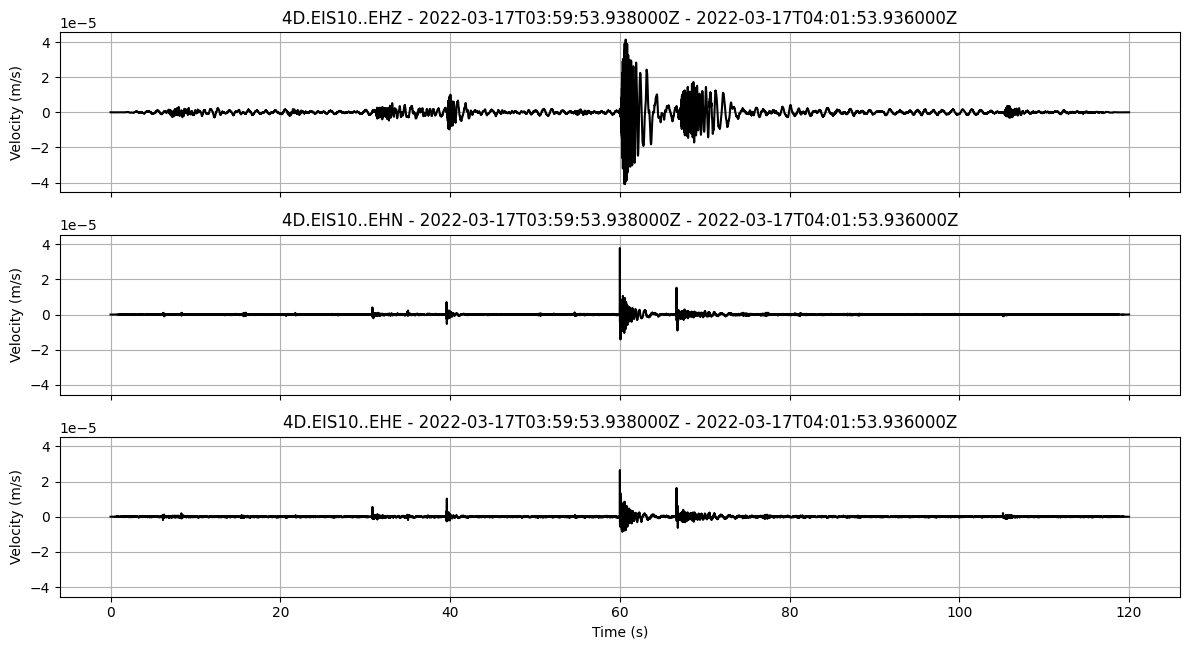

In [2]:
# Plot the entire 2-min seismometer data (single file)

# --- No need to make changes below this line for the user ---
tr_eis10_z = obspy.read('LakeIceExample_CW_EIS10_Z.mseed')
tr_eis10_n = obspy.read('LakeIceExample_CW_EIS10_N.mseed')
tr_eis10_e = obspy.read('LakeIceExample_CW_EIS10_E.mseed')

# Combine into a single stream
st = tr_eis10_z
st.append(tr_eis10_n[0])
st.append(tr_eis10_e[0])
ntr = len(st)

# Compute global max absolute amplitude across all traces in the Stream --> used for consistent y-axis limits across all traces
if ntr > 0:
    all_amps = np.hstack([np.abs(tr.data) for tr in st])
else:
    all_amps = np.array([0.0])
max_amp = np.max(all_amps) if all_amps.size > 0 else 0.0
ylim = 1.1 * max_amp

fig, axs = plt.subplots(ntr, 1, sharex=True, figsize=(12, 2.2*ntr))
if ntr == 1:
    axs = [axs]
for i, tr in enumerate(st):
    axs[i].plot(tr.times(), tr.data, 'k-')
    axs[i].set_title(f'{tr.id} - {tr.stats.starttime} - {tr.stats.endtime}')
    axs[i].grid(True)
    axs[i].set_ylim(-ylim, ylim)
    axs[i].set_ylabel('Velocity (m/s)')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.tight_layout()
plt.show()

# 2 - Zoom in on one event

Zoom to the icequake near 2022‑03‑17 04:00:53 UTC and run the cell below to display the three‑component (E, N, Z) recording for this event.

Observations
* The first arrival is energetic on the horizontal components (E and N), with similar positive polarity on both.
* A second, smaller arrival follows, showing opposite polarity on the two horizontal components.
* The vertical (Z) component shows a cigar‑shaped, strongly dispersive wavetrain: high‑frequency (short‑period) energy precedes low‑frequency (long‑period) energy.

Optional
* If you like, zoom to other ice quakes. Do you see differences in the wavefield charatteristics?

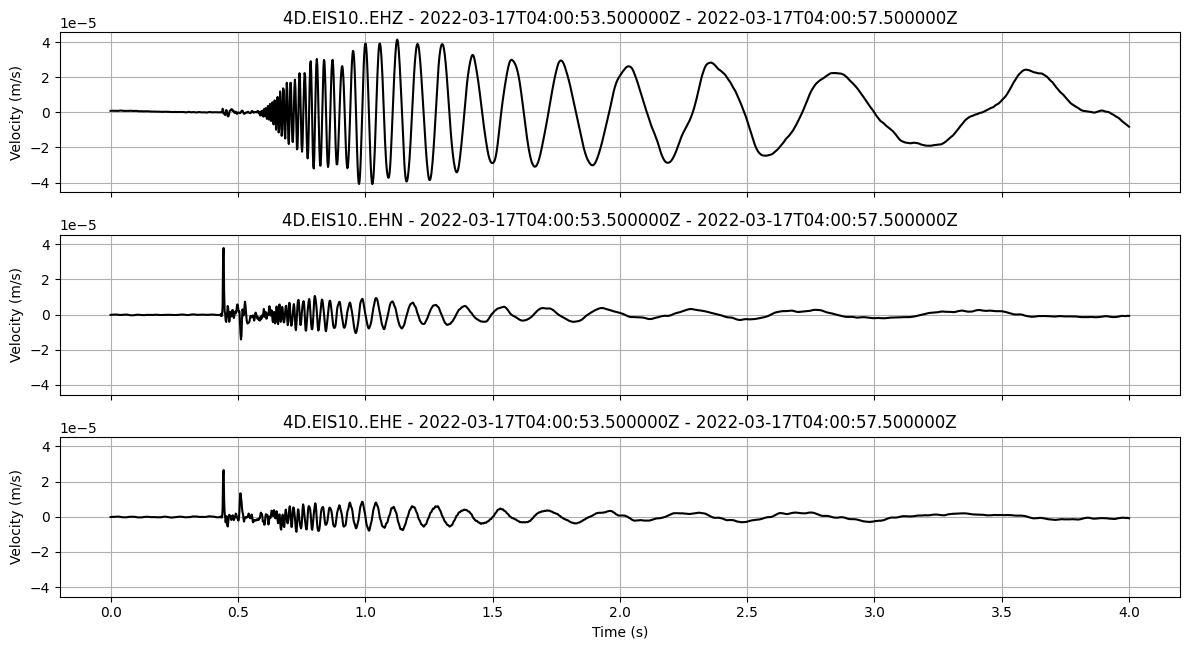

In [3]:
# Set the time window to display
tstart = UTCDateTime('2022-03-17T04:00:53.50')
tend   = UTCDateTime('2022-03-17T04:00:57.50')

# --- No need to make changes below this line for the user ---

st_trim = st.copy().trim(tstart, tend)

ntr = len(st_trim)

# Compute global max absolute amplitude across all traces in the Stream --> used for consistent y-axis limits across all traces
if ntr > 0:
    all_amps = np.hstack([np.abs(tr.data) for tr in st_trim])
else:
    all_amps = np.array([0.0])
max_amp = np.max(all_amps) if all_amps.size > 0 else 0.0
ylim = 1.1 * max_amp

fig, axs = plt.subplots(ntr, 1, sharex=True, figsize=(12, 2.2*ntr))
if ntr == 1:
    axs = [axs]
for i, tr in enumerate(st_trim):
    axs[i].plot(tr.times(), tr.data, 'k-')
    axs[i].set_title(f'{tr.id} - {tr.stats.starttime} - {tr.stats.endtime}')
    axs[i].grid(True)
    axs[i].set_ylim(-ylim, ylim)
    axs[i].set_ylabel('Velocity (m/s)')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.tight_layout()
plt.show()

# 3 - Wavefield components

Rotate the recorded wavefield from E–N–Z to R–T–Z (R = radial, T = transverse, Z = vertical) to separate motion that is radial, transverse or vertical with respect to the source. Run the cell below to perform the rotation and view Z, R and T traces.

Key points
* The supplied rotation uses a back‑azimuth (baz) of 41° chosen to minimise residual horizontal energy for the quasi‑Scholte wavetrain; after rotation the qS energy is concentrated on Z and R.

Typical interpretation after rotation - in order of arrival time:
- $QS_O$: fundamental-mode symmetric quasi‑Lamb wave – appears most prominent on R;
- $SH$: horizontally polarized shear wave – appears most prominent on T
- $QS$: dispersive quasi‑Scholte wave – appears most prominent on Z and R

Tasks
* Run the rotation cell and inspect Z, R and T. Note whether the chosen baz = 41° aligns the energy as described.
* Verify arrival assignments by comparing relative amplitudes and polarity across R, T and Z.
* If the rotation leaves significant energy on T for the $QS$ window, try ±5–10° adjustments to baz and observe the effect.
* Record the final baz used and the arrival times (seconds from trace start) that you assign to each mode.


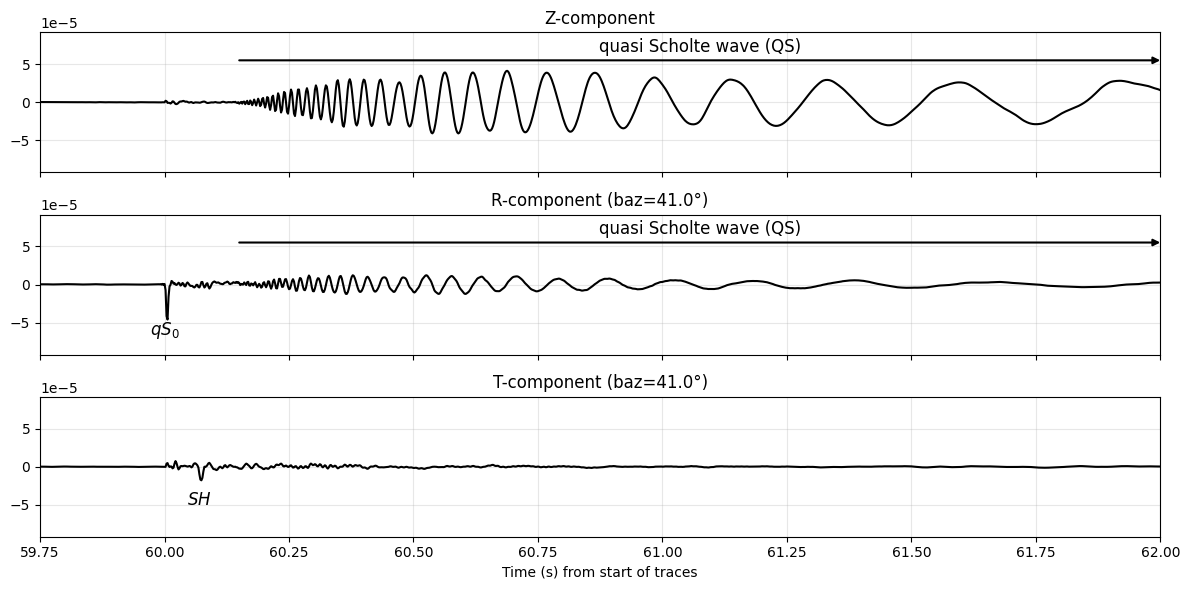

In [4]:
# Set the time window to display (e.g., around the qS0 arrival at ~60s)
window_start_time = 59.75 # in seconds from start of traces
window_end_time = 62.0

# Set the back-azimuth for rotation (degrees)
baz = 41

# --- No need to make changes below this line for the user ---

r, t = rotate_ne_rt(tr_eis10_n[0].data, tr_eis10_e[0].data, baz)
trR = tr_eis10_z.copy(); trT = tr_eis10_z.copy()
trR[0].data = r
trT[0].data = t

# compute global max absolute amplitude across Z, R, T and set symmetric y-limits
all_amps = np.concatenate((np.abs(tr_eis10_z[0].data), np.abs(trR[0].data), np.abs(trT[0].data)))
max_amp = np.max(all_amps) if all_amps.size > 0 else 0.0
ylim = 2.0 * max_amp
fig, axs = plt.subplots(3,1, sharex=True, figsize=(12,6))
axs[0].plot(tr_eis10_z[0].times(), tr_eis10_z[0].data, 'k-'); axs[0].set_title('Z-component')
axs[1].plot(trR[0].times(), trR[0].data, 'k-'); axs[1].set_title(f'R-component (baz={baz:.1f}°)')
axs[2].plot(trT[0].times(), trT[0].data, 'k-'); axs[2].set_title(f'T-component (baz={baz:.1f}°)')
for ax in axs:
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-ylim, ylim)
    ax.set_xlim(window_start_time, window_end_time)  # adjust x-limits to zoom in on the interesting part (e.g., around qS arrival)
axs[-1].set_xlabel('Time (s) from start of traces')

# Draw a horizontal arrow of given length (seconds) starting at x0 at NN% height
time_start_qs0 = 60.0       # start time of qS0 arrival (s) - adjust as needed based on the plot
x0 = 0.15 + time_start_qs0          # start time (s)
length = np.min([3.5, window_end_time - 60 - 0.15]) # arrow length (s)
y = 0.8                     # 80% of axes height (axes coords)

# ensure axs is indexable
arr = axs if isinstance(axs, (list, tuple, np.ndarray)) else [axs]

for ax in (arr[0], arr[1]):
    ax.annotate(
        '',
        xy=(x0 + length, y),
        xytext=(x0, y),
        xycoords=ax.get_xaxis_transform(),            # x in data, y in axes (0..1)
        arrowprops=dict(arrowstyle='-|>', color='k', lw=1.5, shrinkA=0, shrinkB=0),
        clip_on=False
    )

# optional: add centered label on each arrow
arr[0].text(x0 + length/2, y + 0.03, 'quasi Scholte wave (QS)', transform=arr[0].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')
arr[1].text(x0 + length/2, y + 0.03, 'quasi Scholte wave (QS)', transform=arr[1].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')


axs[1].text(0 + time_start_qs0, 0.1, r'$qS_0$', transform=axs[1].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')
axs[2].text(0.07 + time_start_qs0, 0.2, r'$SH$', transform=axs[2].get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color='k')

plt.tight_layout()
plt.show()

# 5 - Hodograms (Particle motion)

Examine particle motion using hodograms for short time windows to characterise wave polarization and particle motion.

Adjust the `starts` list and `window` length below to select analysis windows. Each start time produces a row of three hodograms: R vs Z, T vs Z, and R vs T.

Suggested picks (from the rotated traces):
- $QS_0$: ~60 s
- $SH$: ~60.07 s
- $QS$: starting at around 60.15 s

Tasks
* Run the hodogram cell and inspect the three hodogram columns for each start time.
* For each row, note the dominant polarization and whether motion is linear, elliptical or circular.

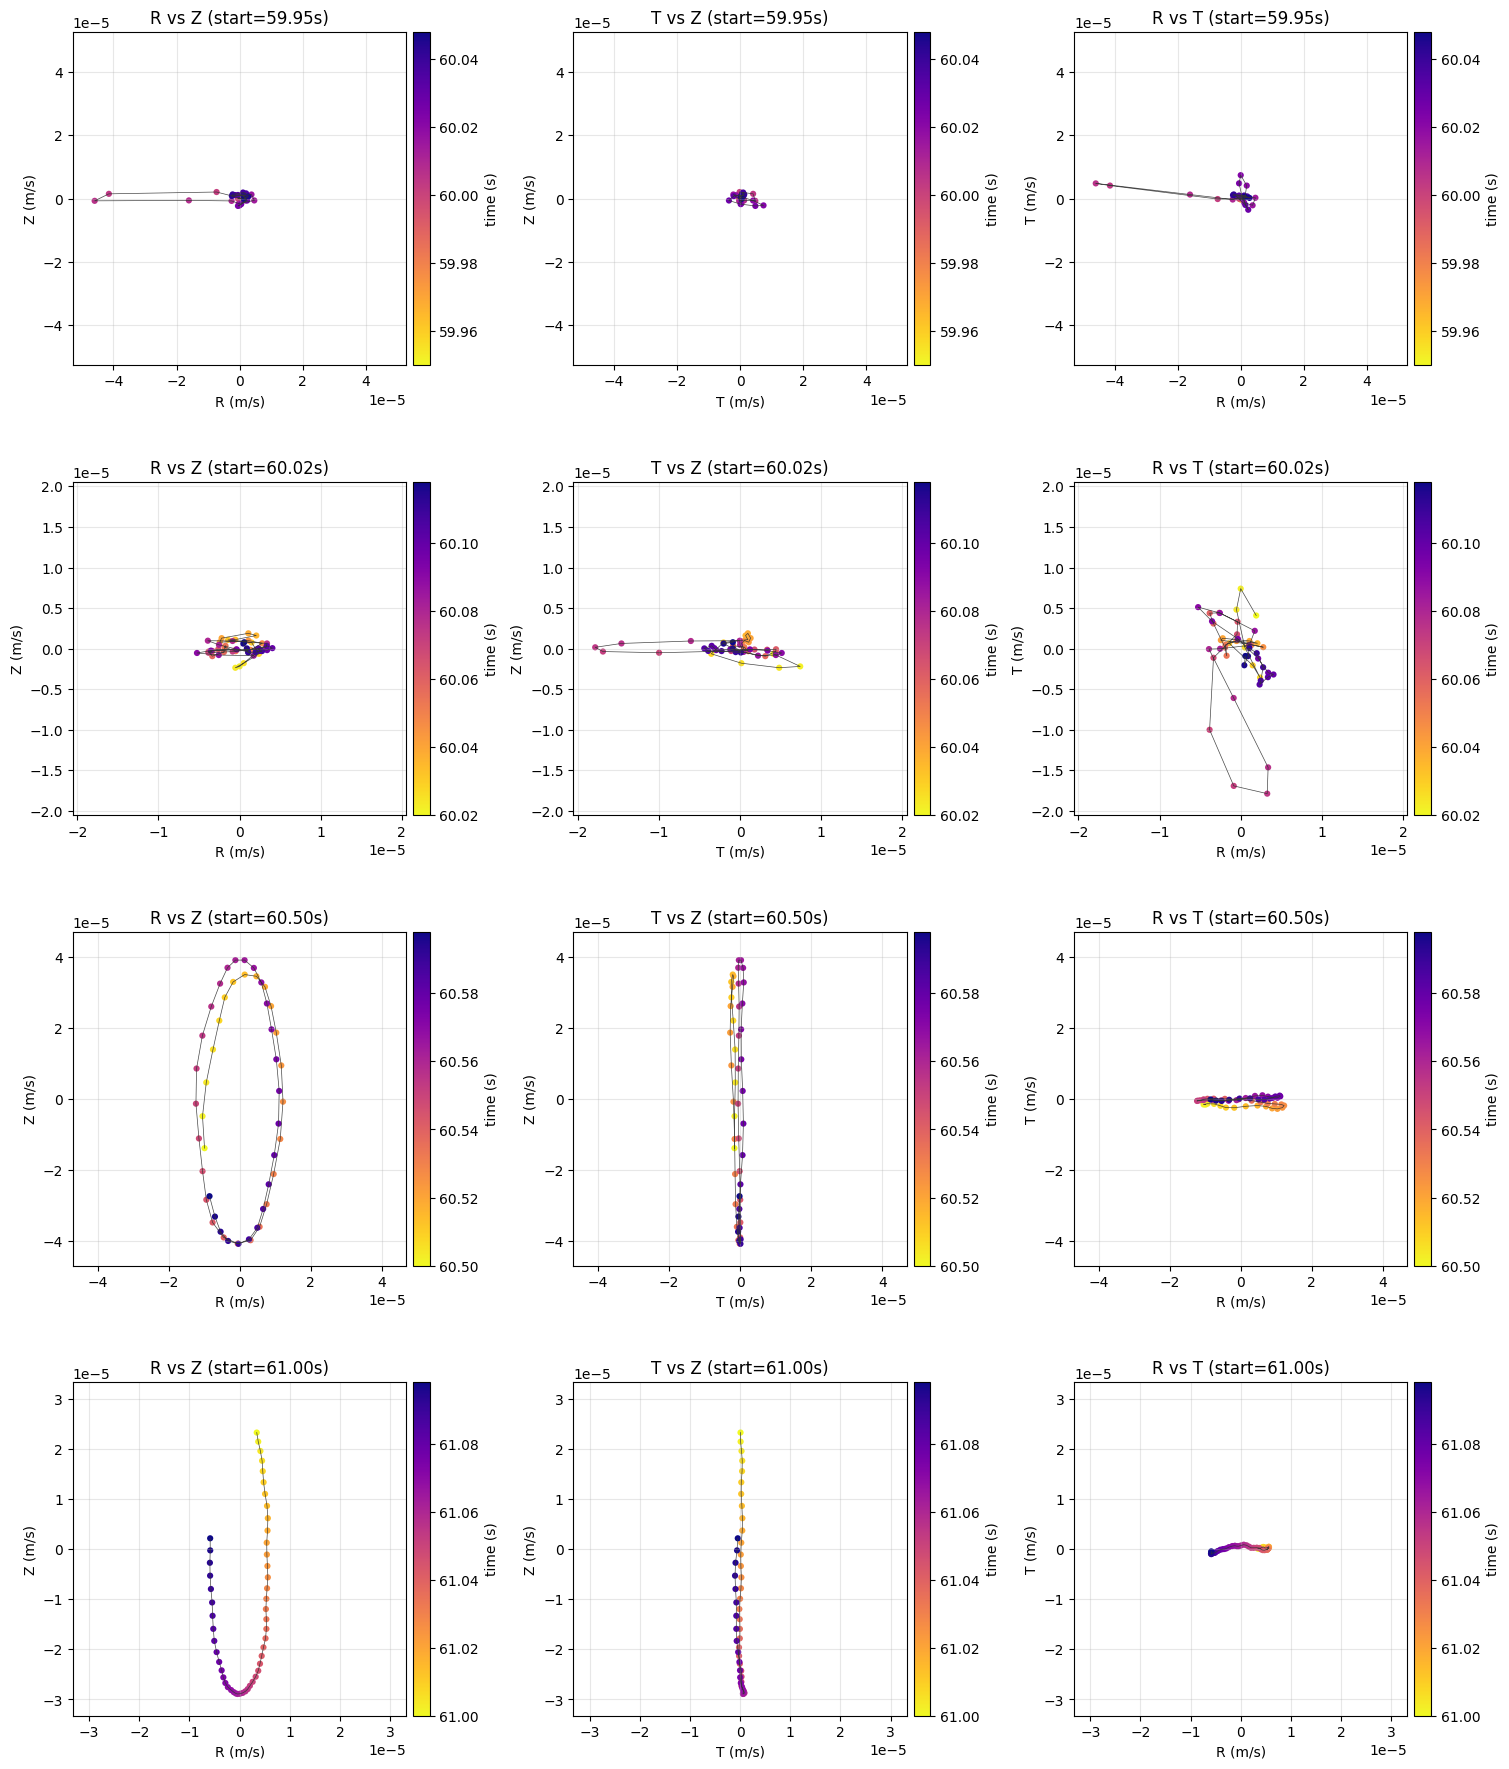

In [5]:
# Plot hodograms for three different time windows (R vs Z, E vs Z, R vs T)

# Set the start times and window length for the hodogram matrix
starts = [59.95, 60.02, 60.5, 61.0]         # seconds from start of traces
window = 0.1                                # window length in seconds


# --- No need to make changes below this line for the user ---

from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

trZ = tr_eis10_z.copy()

def plot_hodogram_matrix(trR, trT, trZ, starts, window, dt=None, cmap='plasma', markersize=6):
    # extract arrays + dt
    if hasattr(trR[0], 'data'):
        r_all = np.asarray(trR[0].data, dtype=float)
        t_all = np.asarray(trT[0].data, dtype=float)
        z_all = np.asarray(trZ[0].data, dtype=float)
        dt = trR[0].stats.delta if dt is None else dt
    else:
        r_all = np.asarray(trR[0].data, dtype=float)
        t_all = np.asarray(trT[0].data, dtype=float)
        z_all = np.asarray(trZ[0].data, dtype=float)
        if dt is None:
            raise ValueError("When passing arrays, supply dt (sampling interval).")

    npts = len(r_all)
    nrows = len(starts)
    fig, axs = plt.subplots(nrows, 3, figsize=(15, 4.5 * nrows), constrained_layout=True)
    if nrows == 1:
        axs = axs[np.newaxis, :]  # make indexing consistent

    pairs = [('R','Z'), ('T','Z'), ('R','T')]

    for row, start in enumerate(starts):
        idx0 = int(np.round(start / dt))
        nwin = int(np.round(window / dt))
        idx1 = min(idx0 + nwin, npts)
        if idx0 < 0:
            idx0 = 0

        # windows for this row
        r_win = r_all[idx0:idx1]
        t_win = t_all[idx0:idx1]
        z_win = z_all[idx0:idx1]
        times_win = np.arange(idx0, idx1) * dt

        # per-row common symmetric limit from all components
        arrays = [a for a in (r_win, t_win, z_win) if a.size > 0]
        m_row = max(np.max(np.abs(a)) for a in arrays) if arrays else 0.0
        lim_row = 1.15 * m_row if m_row > 0 else 1.0

        for col, (xa, ya) in enumerate(pairs):
            ax = axs[row, col]
            if xa == 'R' and ya == 'Z':
                xx, yy = r_win, z_win
            elif xa == 'T' and ya == 'Z':
                xx, yy = t_win, z_win
            elif xa == 'R' and ya == 'T':
                xx, yy = r_win, t_win
            else:
                xx, yy = np.array([]), np.array([])

            if xx.size == 0 or yy.size == 0:
                ax.text(0.5, 0.5, 'empty window', transform=ax.transAxes, ha='center')
                ax.set_xlim(-lim_row, lim_row); ax.set_ylim(-lim_row, lim_row)
                ax.set_xlabel(f'{xa} (units)'); ax.set_ylabel(f'{ya} (units)')
                ax.set_title(f'{xa} vs {ya} (start={start:.2f}s)')
                continue

            norm = Normalize(vmin=times_win[0], vmax=times_win[-1])
            sc = ax.scatter(xx, yy, c=times_win, cmap=cmap + '_r', s=markersize, norm=norm, edgecolors='none')
            ax.plot(xx, yy, color='0.2', linewidth=0.5, alpha=0.9)
            ax.set_xlim(-lim_row, lim_row); ax.set_ylim(-lim_row, lim_row)
            ax.set_aspect('equal', 'box'); ax.grid(True, alpha=0.3)
            ax.set_xlabel(f'{xa} (m/s)'); ax.set_ylabel(f'{ya} (m/s)')
            ax.set_title(f'{xa} vs {ya} (start={start:.2f}s)')
            cbar = fig.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, fraction=0.05)
            cbar.set_label('time (s)')

    return fig, axs

fig, axs = plot_hodogram_matrix(trR, trT, trZ, starts, window, cmap='plasma', markersize=20)
plt.show()

# 5 - Spectrogram

Compute a time–frequency representation of the vertical trace by running the cell below. Use the spectrogram to visualise dispersion in the $QS$ wavetrain.

Observations
* Anomalous dispersion of the $QS$ wavetrain: high frequencies arrive before low frequencies.
* Energetic frequency bands and their arrival times across the selected window.

Suggestions
E* xample time window: start ≈ 59 s, duration ≈ 6 s (e.g., `trace_start_time = 59`, `spectrogram_window = 6.0`).
* Frequency range: 1–250 Hz (reduce `f_min` to focus on long-period energy if desired).

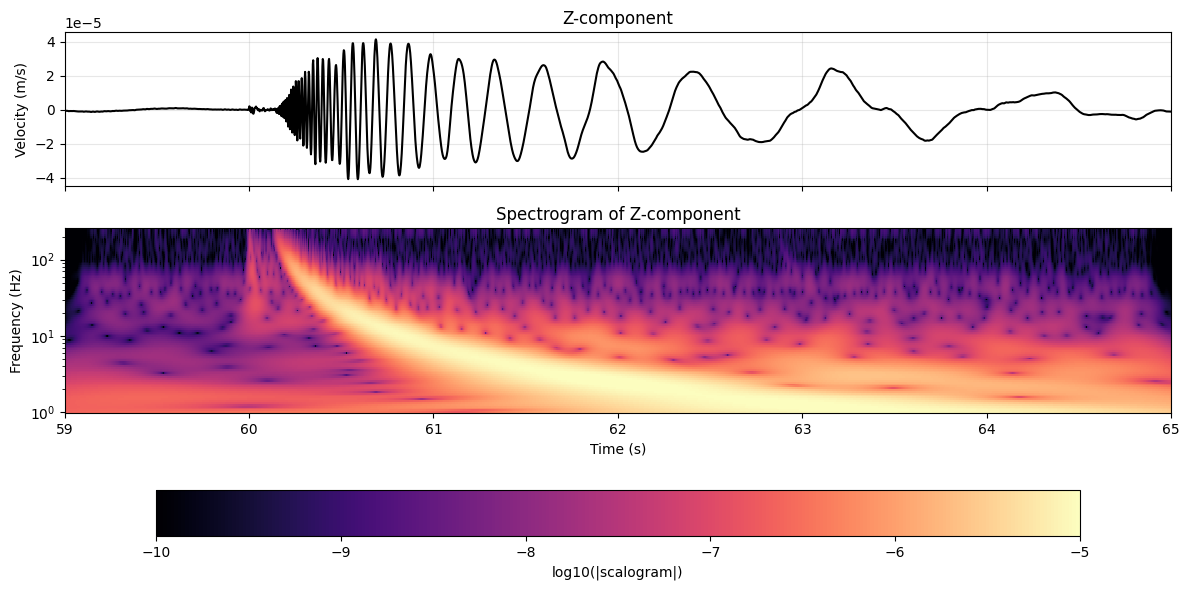

In [6]:
# Trim for more focused time-frequency analysis around the qS0 arrival (e.g., 59-65s)
trace_start_time = 59
spectrogram_window = 6.0  # Set the time window duration for the spectrogram (e.g., 6 seconds to cover 59-65s)

# Frequency range for the scalogram
f_min = 1
f_max = 250 # Note: 250 Hz is the Nyquist frequency for a 500 Hz sampling rate, so we cannot go above that.


# --- No need to make changes below this line for the user ---

start_time = tr_eis10_z[0].stats.starttime
tr_trim = tr_eis10_z.copy().trim(start_time + trace_start_time, start_time + trace_start_time + spectrogram_window)
tr_trim.taper(max_percentage=0.05)
npts = tr_trim[0].stats.npts
dt = tr_trim[0].stats.delta
t = np.linspace(0, dt * npts, npts)


scalogram = cwt(tr_trim[0].data, dt, 5, f_min, f_max)

x, y = np.meshgrid(
    t,
    np.logspace(np.log10(f_min), np.log10(f_max), scalogram.shape[0]))

fig, axs = plt.subplots(2,1, sharex=True, figsize=(12,6),
                        gridspec_kw={'height_ratios':[1,2]})  # first axis half the height of second

axs[0].plot(tr_eis10_z[0].times(), tr_eis10_z[0].data, 'k-'); axs[0].set_title('Z-component')
axs[0].grid(True, alpha=0.3)
axs[0].set_xlim(trace_start_time, trace_start_time + spectrogram_window)
axs[0].set_ylabel('Velocity (m/s)')

im = axs[1].pcolormesh(x + trace_start_time, y, np.log10(np.abs(scalogram)), cmap='magma', vmin=-10, vmax=-5)
cbar = fig.colorbar(im, ax=axs[1], orientation='horizontal', pad=0.25, shrink=0.95)
cbar.set_label('log10(|scalogram|)')
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Frequency (Hz)")
axs[1].set_yscale('log')
axs[1].set_title('Spectrogram of Z-component')

plt.tight_layout()
plt.show()  